In [28]:
import pandas as pd
import matplotlib.pyplot as plt

t_serial = float(pd.read_csv("../Etapa 0/resultados.csv")["tempo"].mean())

res = pd.read_csv("resultados2.csv")
r1 = res[res["threads_per_block"]==128]
r2 = res[res["threads_per_block"]==256]
r3 = res[res["threads_per_block"]==512]

r1 = r1.drop(r1["total_ms"].idxmax())
r2 = r2.drop(r2["total_ms"].idxmax())
r3 = r3.drop(r3["total_ms"].idxmax())

r1 = r1.drop(r1["total_ms"].idxmin())
r2 = r2.drop(r2["total_ms"].idxmin())
r3 = r3.drop(r3["total_ms"].idxmin())

resumo = {"block": [], "méd tempo":[], "speedup méd":[], "h2d":[], "d2h":[], "overhead":[]}
for r, n in zip([r1, r2, r3],[128, 256, 512]):
    resumo["block"].append(n)
    resumo["méd tempo"].append(r["total_ms"].mean())
    resumo["speedup méd"].append(t_serial/r["total_ms"].mean())
    resumo["h2d"].append(r["h2d_ms"].mean())
    resumo["d2h"].append(r["d2h_ms"].mean())
    resumo["overhead"].append(r["overhead_ms"].mean())

resumo = pd.DataFrame(resumo)
resumo


,block,méd tempo,speedup méd,h2d,d2h,overhead
0,128,266.682778,6.130955,1.025556,3.827222,2.901111
1,256,265.980000,6.147154,1.022222,3.812222,2.913889
2,512,264.960000,6.170818,0.991111,3.799444,2.773889


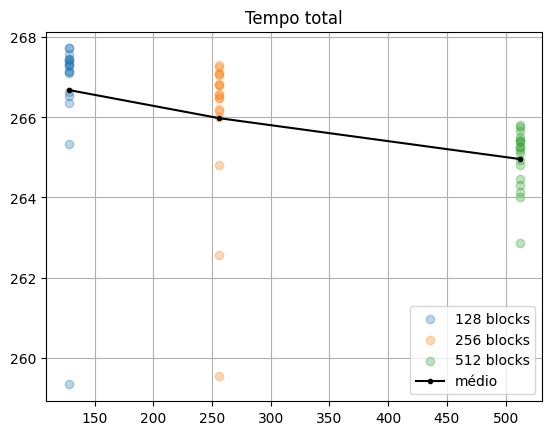

In [36]:
plt.scatter([128]*len(r1), r1["total_ms"], alpha=0.3, label="128 blocks")
plt.scatter([256]*len(r2), r2["total_ms"], alpha=0.3, label="256 blocks")
plt.scatter([512]*len(r3), r3["total_ms"], alpha=0.3, label="512 blocks")
plt.plot(resumo["block"], resumo["méd tempo"], marker=".", color="black", label="médio")
plt.grid()
plt.legend()
plt.title("Tempo total")
plt.show()

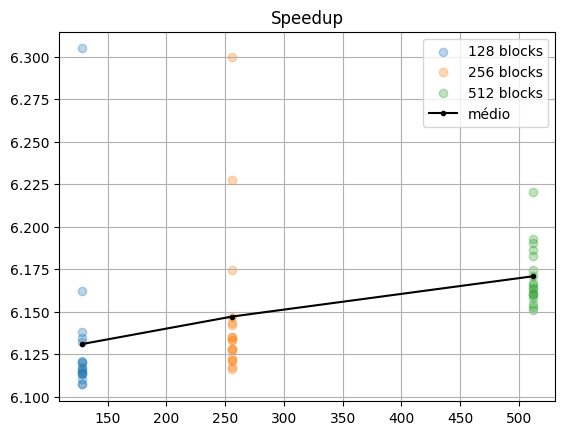

In [38]:
plt.title("Speedup")
plt.scatter([128]*len(r1), t_serial/r1["total_ms"], alpha=0.3, label="128 blocks")
plt.scatter([256]*len(r2), t_serial/r2["total_ms"], alpha=0.3, label="256 blocks")
plt.scatter([512]*len(r3), t_serial/r3["total_ms"], alpha=0.3, label="512 blocks")
plt.plot(resumo["block"], t_serial/resumo["méd tempo"], marker=".", color="black", label="médio")
plt.legend()
plt.grid()


In [39]:
r1

,threads_per_block,iteracoes,sse,h2d_ms,d2h_ms,kernel_ms,total_ms,overhead_ms
1,128,50,24.665393,0.95,3.47,260.10,267.17,2.66
2,128,50,24.665393,1.01,3.57,259.18,266.54,2.77
3,128,50,24.665393,0.97,3.71,259.99,267.34,2.67
4,128,50,24.665393,0.97,3.82,260.17,267.72,2.76
5,128,50,24.665393,0.97,3.70,259.98,267.31,2.65
6,128,50,24.665393,1.05,3.66,260.06,267.39,2.62
7,128,50,24.665393,0.96,3.63,260.22,267.46,2.66
8,128,50,24.665393,1.04,3.83,259.75,267.42,2.80
9,128,50,24.665393,1.14,4.36,250.18,259.33,3.66
10,128,50,24.665393,1.13,4.47,257.38,266.63,3.66


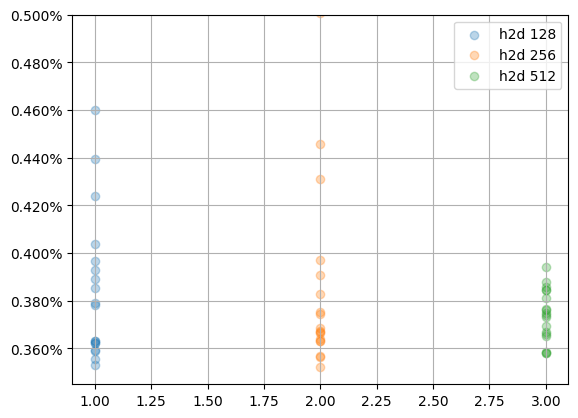

In [55]:
import matplotlib.ticker as mtick

for df in [r1, r2, r3]:
    df["h2d percentage"] = df.h2d_ms / df.total_ms
    df["d2h percentage"] = df.d2h_ms / df.total_ms

ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

plt.scatter([1]*len(r1), r1["h2d percentage"], alpha=0.3, label="h2d 128")
plt.scatter([2]*len(r2), r2["h2d percentage"], alpha=0.3, label="h2d 256")
plt.scatter([3]*len(r3), r3["h2d percentage"], alpha=0.3, label="h2d 512")
plt.legend()
plt.ylim(top=0.005)
plt.grid(True)
plt.show()

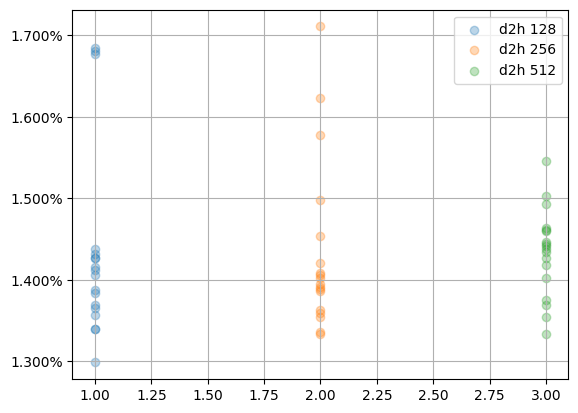

In [54]:
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

plt.scatter([1]*len(r1), r1["d2h percentage"], alpha=0.3, label = "d2h 128")
plt.scatter([2]*len(r2), r2["d2h percentage"], alpha=0.3, label = "d2h 256")
plt.scatter([3]*len(r3), r3["d2h percentage"], alpha=0.3, label = "d2h 512")
plt.grid(True)
plt.legend()
plt.show()

Os tempos de h2d são muito reduzidos (<0.5%), enquanto d2h são consideráveis mas, ainda reduzidos (<2%)